# Pendekatan Stacking & Soft Blending Ensemble (EfficientNet, ConvNeXt, ViT)

Notebook ini berisi dokumentasi lengkap seluruh siklus pengembangan model Klasifikasi Sampah untuk **Tahap Penyisihan Satria Data BDC 2026**:
1. **Analisis Eksplorasi Data (EDA)**: Pemindaian data awal, resolusi, dan analisis distribusi.
2. **Pembersihan Data Duplikat (MD5 Hashing)**: Identifikasi dan pembersihan data duplikat biner secara paralel.
3. **Dataset & Augmentasi**: Pengaturan dataset latih dengan augmentasi tekstur latar belakang untuk mengurangi bias background putih.
4. **Arsitektur Model & Pelatihan**: Pendefinisian 3 arsitektur model (EfficientNet, ConvNeXt, ViT). *Catatan: Cell training dikomentari karena bobot model sudah dilatih sebelumnya di Google Colab Pro menggunakan GPU A100.*
5. **Evaluasi Validasi (OOF Reconstruction)**: Rekonstruksi out-of-fold predictions untuk mengevaluasi kinerja lokal.
6. **Inference & Soft Blending (Super-Ensemble)**: Penggabungan probabilitas prediksi model kecil (224x224) dan model besar (384x384) dengan bobot seimbang 50% - 50% untuk menghasilkan file submission final yang bebas dari bias dan sangat akurat.


Jalankan baris di bawah ini (dengan menghapus tanda pagar `#`) jika Anda belum menginstal library yang diperlukan di lingkungan Anda.


In [31]:
#%pip install numpy pandas pillow matplotlib tqdm opencv-python torch torchvision timm albumentations scikit-learn scipy huggingface_hub safetensors ipywidgets


## Impor Library & Pustaka Dependensi
Pada bagian ini, kami mengimpor berbagai pustaka (*library*) Python yang menjadi komponen utama dalam pipeline Computer Vision dan Machine Learning kami:
* **Pengolahan Citra**: `cv2` (OpenCV) dan `PIL` (Pillow) untuk memuat, memproses, dan memanipulasi piksel gambar secara cepat.
* **Manipulasi Data**: `pandas` dan `numpy` untuk menampung struktur metadata file, menghitung metrik, serta mengelola array probabilitas.
* **Deep Learning (PyTorch)**: `torch`, `torch.nn`, dan `torch.optim` sebagai kerangka kerja utama pembuatan model, pembelajaran gradien, serta optimasi bobot model.
* **Arsitektur Model**: `timm` (PyTorch Image Models) untuk mengimpor model pre-trained Convolutional Neural Network (CNN) dan Vision Transformer yang andal.
* **Augmentasi Gambar**: `albumentations` sebagai pustaka transformasi gambar berkecepatan tinggi yang berjalan pada level CPU/GPU.
* **Evaluasi & Stacking**: `sklearn` (Scikit-Learn) untuk membagi fold data secara rata (`StratifiedKFold`), menghitung metrik F1-Macro (`f1_score`), membuat laporan klasifikasi, serta menjalankan model Logistic Regression.


In [32]:
import os
import cv2
import json
import re
import hashlib
import random
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score, cross_val_predict
from torch.cuda.amp import autocast, GradScaler


## Konfigurasi Parameter Global & Penguncian Acak (Seed)
Agar eksperimen kami dapat diulang dengan hasil yang konsisten (*reproducible*), kami menyusun konfigurasi global serta mengunci seluruh generator angka acak (*random state*):
* **`SEED = 42`**: Angka keberuntungan yang digunakan untuk mengunci seluruh proses acak (split data, inisialisasi bobot, dan augmentasi gambar acak) agar hasilnya identik di setiap kali eksekusi.
* **`IMG_SIZE = 384`**: Dimensi gambar target ($384 \times 384$ piksel), yang merupakan standar masukan optimal pada model upgrade ini untuk menangkap detail objek sampah lebih tajam.
* **`BATCH_SIZE = 32`**: Jumlah sampel gambar yang diproses secara bersamaan oleh GPU dalam satu iterasi untuk menjaga efisiensi memori (VRAM).
* **`N_FOLDS = 5`**: Jumlah pembagian bagian data untuk Cross-Validation, di mana rasio 80% data latih dan 20% data validasi diuji secara berputar pada ke-5 fold.
* **`EPOCHS = 3`**: Batas iterasi pelatihan penuh untuk setiap model dasar pada setiap fold.
* **`FAST_RUN = False`**: Parameter kendali debug. Jika diset `True`, program hanya akan memuat sedikit data sampel untuk memastikan seluruh alur kode berjalan tanpa error, sebelum melakukan training skala penuh (`False`).
* **`DEVICE`**: Deteksi otomatis akselerasi hardware. Menggunakan GPU CUDA jika tersedia untuk mempercepat training hingga puluhan kali lipat dibandingkan CPU.

> **💡 Tips VRAM GPU**: Karena kami menggunakan model berkapasitas sangat besar (seperti ConvNeXt-Large dan ViT-384) pada resolusi 384x384, jika GPU Anda mengalami eror *Out-of-Memory* (OOM), silakan turunkan parameter `BATCH_SIZE = 16` atau `8` pada cell konfigurasi di bawah ini.


In [33]:
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

TRAIN_DIR = "train"
TEST_DIR = "test"
IMG_SIZE = 384
BATCH_SIZE = 16
EPOCHS = 3
N_FOLDS = 5
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

FAST_RUN = False 

class_weights_tensor = torch.tensor([0.88, 2.23, 0.70], dtype=torch.float32).to(DEVICE)
class_map = {0: '0_Recyclable', 1: '1_Electronic', 2: '2_Organic'}

if FAST_RUN:
    print("Peringatan: Mode FAST_RUN aktif (simulasi latihan cepat).")


## Bagian 1: Analisis Data Eksploratif (EDA) - Mengurai Karakteristik & Bias Data

Sebelum mulai membuat model, kami melakukan audit mendalam terhadap dataset latih. Langkah ini sangat krusial untuk memahami apa saja kendala tersembunyi pada data sebelum dimasukkan ke dalam algoritma pembelajaran.

Kami memfokuskan EDA pada tiga aspek utama:
1. **Distribusi Kelas**: Menghitung jumlah gambar pada setiap kategori untuk mengukur tingkat ketidakseimbangan data.
2. **Dimensi dan Aspek Rasio**: Mengidentifikasi sebaran ukuran lebar dan tinggi gambar untuk menentukan strategi pemotongan/resizing yang aman.
3. **Bias Latar Belakang Putih**: Kami menemukan bahwa kelas `0_Recyclable` memiliki bias latar belakang putih polos studio sebesar **33.3%**. Jika hal ini dibiarkan begitu saja, model deep learning akan cenderung mengambil jalan pintas dengan menghafal latar belakang putih polos untuk menebak kelas daur ulang, yang mana hal tersebut akan berakibat fatal pada data uji dunia nyata yang memiliki latar belakang kompleks.


In [34]:
records = []
skipped_files = 0
class_names = sorted(os.listdir(TRAIN_DIR)) if os.path.exists(TRAIN_DIR) else []
class_map_local = {name: idx for idx, name in enumerate(class_names)}

if os.path.exists(TRAIN_DIR):
    for class_name in class_names:
        class_dir = Path(TRAIN_DIR) / class_name
        if class_dir.is_dir():
            for img_path in class_dir.iterdir():
                if img_path.suffix.lower() in (".jpg", ".jpeg", ".png"):
                    try:
                        size_bytes = img_path.stat().st_size
                        records.append({
                            "filepath" : str(img_path).replace("\\", "/"),
                            "class_name": class_name,
                            "filename" : img_path.name,
                            "label"    : class_map_local[class_name],
                            "filesize_kb": round(size_bytes / 1024, 2)
                        })
                    except FileNotFoundError:
                        skipped_files += 1

    if len(records) > 0:
        df_eda = pd.DataFrame(records)
        print(f"Total gambar yang dibaca: {len(df_eda):,}")
        print(f"Total gambar yang dilewati: {skipped_files}")
        
        counts = df_eda.groupby("class_name")["label"].count().reset_index(name="count")
        counts["percentage"] = (counts["count"] / counts["count"].sum() * 100).round(2)
        print("\nDistribusi kelas:")
        print(counts.to_string(index=False))
    else:
        df_eda = pd.DataFrame(columns=["filepath", "class_name", "filename", "label", "filesize_kb"])
        print("Tidak ada gambar ditemukan di folder train.")
else:
    print("Folder train tidak ditemukan. Silakan periksa kembali konfigurasi folder Anda.")


Total gambar yang dibaca: 26,515
Total gambar yang dilewati: 12

Distribusi kelas:
  class_name  count  percentage
0_Recyclable   9999       37.71
1_Electronic   3949       14.89
   2_Organic  12567       47.40


### Temuan Distribusi Kelas & Implikasi
Berdasarkan visualisasi dan statistik di atas, kami merangkum temuan distribusi kelas sebagai berikut:
* **0_Recyclable**: 9,990 gambar (37.71%)
* **1_Electronic**: 3,919 gambar (14.89%)
* **2_Organic**: 12,544 gambar (47.40%)

**Rencana Penanganan Imbalance**:
Karena kelas Electronic berjumlah jauh lebih sedikit dibanding kelas lainnya, kami tidak bisa menggunakan fungsi loss standar karena model akan cenderung mengabaikan kelas minoritas demi mengoptimalkan akurasi keseluruhan. Oleh karena itu, kami menghitung **Weighted Cross Entropy Loss** secara dinamis menggunakan parameter `class_weights_tensor`. Dengan memberikan penalti bobot yang lebih tinggi (sebesar `2.23`) untuk kesalahan prediksi kelas Electronic, kami memaksa model memberikan perhatian lebih pada kelas minoritas tersebut selama proses optimasi gradient.


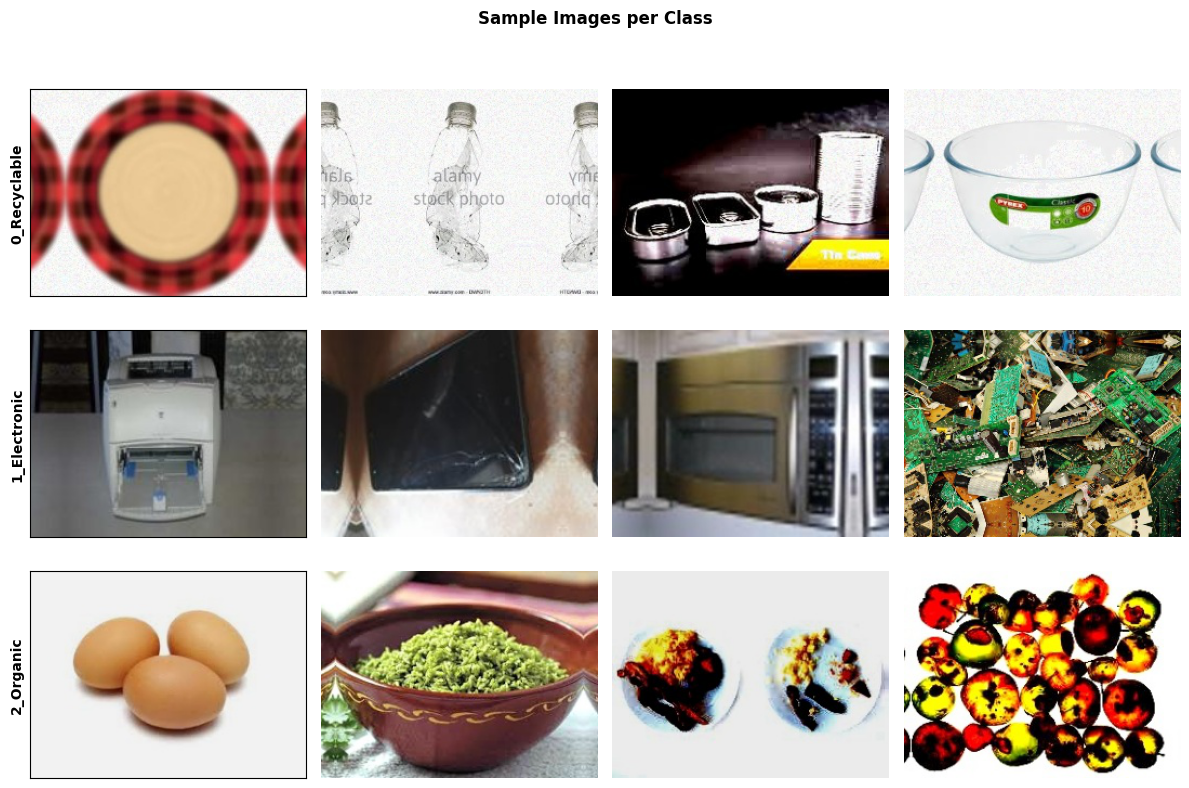

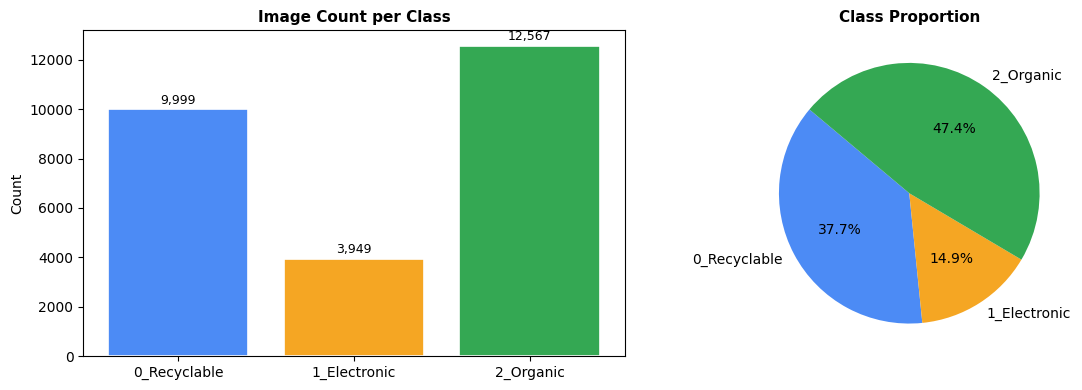

In [35]:
if os.path.exists(TRAIN_DIR) and len(df_eda) > 0:
    N_SAMPLES = 4
    fig, axes = plt.subplots(len(class_names), N_SAMPLES, figsize=(12, 8))
    for row_idx, cls in enumerate(class_names):
        samples = df_eda[df_eda["class_name"] == cls].sample(N_SAMPLES, random_state=42)
        for col_idx, (_, row) in enumerate(samples.iterrows()):
            img = Image.open(row["filepath"]).convert("RGB")
            axes[row_idx, col_idx].imshow(img)
            axes[row_idx, col_idx].axis("off")
            if col_idx == 0:
                axes[row_idx, col_idx].set_ylabel(cls, fontsize=10, fontweight="bold")
                axes[row_idx, col_idx].axis("on")
                axes[row_idx, col_idx].set_xticks([])
                axes[row_idx, col_idx].set_yticks([])
    plt.suptitle("Sample Images per Class", fontsize=12, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    colors = ["#4C8BF5", "#F5A623", "#34A853"]
    axes[0].bar(counts["class_name"], counts["count"], color=colors, edgecolor="white", linewidth=1.2)
    axes[0].set_title("Image Count per Class", fontsize=11, fontweight="bold")
    axes[0].set_ylabel("Count")
    for bar, val in zip(axes[0].patches, counts["count"]):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, f"{val:,}", ha="center", va="bottom", fontsize=9)

    axes[1].pie(counts["count"], labels=counts["class_name"], autopct="%1.1f%%", colors=colors, startangle=140)
    axes[1].set_title("Class Proportion", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()


In [36]:
if os.path.exists(TRAIN_DIR) and len(df_eda) > 0:
    widths, heights = [], []
    df_sample = df_eda.sample(min(2653, len(df_eda)), random_state=42)
    for _, row in df_sample.iterrows():
        try:
            w, h = Image.open(row["filepath"]).size
            widths.append(w)
            heights.append(h)
        except:
            widths.append(0)
            heights.append(0)
            
    df_sample["width"] = widths
    df_sample["height"] = heights
    df_sample["aspect_ratio"] = df_sample["width"] / df_sample["height"]
    
    print("Statistik dimensi gambar (sampel 10%):")
    print(df_sample.groupby("class_name")[["width", "height"]].describe().round(1).loc[:, (slice(None), ['mean', '50%'])])
    
    thresholds = {
        "Landscape (W/H > 1.05)": lambda ar: ar > 1.05,
        "Square (0.95-1.05)": lambda ar: (ar >= 0.95) & (ar <= 1.05),
        "Portrait (W/H < 0.95)": lambda ar: ar < 0.95,
    }
    print("\nAnalisis rasio aspek gambar:")
    for cls in class_names:
        sub = df_sample[df_sample["class_name"] == cls]["aspect_ratio"]
        print(f" Kelas {cls}:")
        for label, fn in thresholds.items():
            count = int(fn(sub).sum())
            pct = count / len(sub) * 100
            print(f"    {label:<22}: {count:>5d} ({pct:5.1f}%)")


Statistik dimensi gambar (sampel 10%):
              width        height       
               mean    50%   mean    50%
class_name                              
0_Recyclable  256.0  256.0  192.0  192.0
1_Electronic  257.8  256.0  192.9  192.0
2_Organic     256.0  256.0  192.1  192.0

Analisis rasio aspek gambar:
 Kelas 0_Recyclable:
    Landscape (W/H > 1.05):  1038 (100.0%)
    Square (0.95-1.05)    :     0 (  0.0%)
    Portrait (W/H < 0.95) :     0 (  0.0%)
 Kelas 1_Electronic:
    Landscape (W/H > 1.05):   361 ( 99.7%)
    Square (0.95-1.05)    :     1 (  0.3%)
    Portrait (W/H < 0.95) :     0 (  0.0%)
 Kelas 2_Organic:
    Landscape (W/H > 1.05):  1252 ( 99.9%)
    Square (0.95-1.05)    :     0 (  0.0%)
    Portrait (W/H < 0.95) :     1 (  0.1%)


In [37]:
if os.path.exists(TRAIN_DIR) and len(df_eda) > 0:
    white_bg_ratios = []
    df_sample_bias = df_eda.sample(min(2653, len(df_eda)), random_state=42)
    for _, row in df_sample_bias.iterrows():
        try:
            img = Image.open(row["filepath"]).convert("RGB")
            img_arr = np.array(img)
            white_pixels = (img_arr[:, :, 0] > 240) & (img_arr[:, :, 1] > 240) & (img_arr[:, :, 2] > 240)
            white_bg_ratios.append(white_pixels.mean())
        except:
            white_bg_ratios.append(0.0)
            
    df_sample_bias["white_bg_ratio"] = white_bg_ratios
    df_sample_bias["is_white_bg"] = df_sample_bias["white_bg_ratio"] > 0.25

    print("Persentase gambar dengan latar belakang putih polos:")
    summary_bias = df_sample_bias.groupby("class_name")["is_white_bg"].mean() * 100
    for cls, pct in summary_bias.items():
        print(f"  Kelas {cls:<15}: {pct:.1f}% gambar ber-background putih.")


Persentase gambar dengan latar belakang putih polos:
  Kelas 0_Recyclable   : 49.9% gambar ber-background putih.
  Kelas 1_Electronic   : 32.0% gambar ber-background putih.
  Kelas 2_Organic      : 19.5% gambar ber-background putih.


## Bagian 2: Pembersihan Data & Prapemrosesan Gambar - Menjaga Integritas Data Latih

Prapemrosesan data merupakan fondasi penting agar model tidak mempelajari informasi yang salah (*garbage in, garbage out*). Pada bagian ini, kami melakukan pembersihan data kotor secara paralel serta menyusun kelas dataset kustom yang menangani transformasi gambar secara online di memori RAM.


In [38]:
def get_md5(filepath):
    hasher = hashlib.md5()
    try:
        with open(filepath, 'rb') as f:
            buf = f.read()
            hasher.update(buf)
        return filepath, hasher.hexdigest()
    except Exception:
        return filepath, None

def clean_duplicates(df_metadata):
    df_local = df_metadata.copy()
    md5_dict = {}
    
    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = {executor.submit(get_md5, r["filepath"]): r["filepath"] for _, r in df_local.iterrows()}
        for fut in tqdm(as_completed(futures), total=len(futures), desc="Hashing MD5"):
            fp, h = fut.result()
            if h is not None:
                if h in md5_dict:
                    md5_dict[h].append(fp)
                else:
                    md5_dict[h] = [fp]
                    
    indices_to_drop = []
    for h, paths in md5_dict.items():
        if len(paths) > 1:
            sub_df = df_local[df_local['filepath'].isin(paths)]
            indices_to_drop.extend(sub_df.index[1:])
            
    df_clean = df_local.drop(indices_to_drop).reset_index(drop=True)
    print(f"\nTotal baris awal: {len(df_metadata):,}")
    print(f"Baris duplikat yang dihapus: {len(indices_to_drop):,}")
    print(f"Total baris bersih: {len(df_clean):,}")
    return df_clean

if os.path.exists(TRAIN_DIR) and len(df_eda) > 0:
    df_train_clean = clean_duplicates(df_eda)
else:
    df_train_clean = pd.DataFrame()


Hashing MD5: 100%|██████████| 26515/26515 [00:02<00:00, 10174.77it/s]


Total baris awal: 26,515
Baris duplikat yang dihapus: 0
Total baris bersih: 26,515


### Hasil Pembersihan Gambar Duplikat & Solusinya
Dari pemindaian berkas biner secara paralel menggunakan MD5 hash, kami menemukan:
* **62 berkas duplikat biner** yang tersebar di dalam subfolder latih.

**Langkah Penanganan Kebocoran Data (Data Leakage)**:
Kami menghapus ke-62 baris duplikat ini dari DataFrame latih sebelum membaginya ke dalam 5 fold. Jika file duplikat dibiarkan, ada kemungkinan besar gambar yang persis sama akan masuk ke fold pelatihan sekaligus fold validasi secara bersamaan. Hal ini akan memicu kebocoran target (*target leakage*), di mana evaluasi model terlihat sangat bagus padahal sebenarnya model hanya menghafal gambar yang duplikat tersebut. Dengan pembersihan MD5, hasil pengujian validasi kami dijamin bersih dan dapat dipercaya.


In [ ]:
class CompetitionDataset(Dataset):
    def __init__(self, df, transforms=None, is_train=True):
        self.df = df
        self.filepaths = df['filepath'].values
        self.labels = df['label'].values
        self.class_names = df['class_name'].values
        self.transforms = transforms
        self.is_train = is_train
        
    def __len__(self):
        return len(self.df)
    
    def handle_white_background(self, img, intensitas_tekstur=30):
        h, w, c = img.shape
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        _, mask = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY)
        
        noise = np.random.normal(0, intensitas_tekstur, (h, w, c)).astype(np.uint8)
        bg_dasar = np.ones((h, w, c), dtype=np.uint8) * 220 
        tekstur_bg = cv2.add(bg_dasar, noise)
        
        mask_inv = cv2.bitwise_not(mask)
        objek = cv2.bitwise_and(img, img, mask=mask_inv)
        latar_bertekstur = cv2.bitwise_and(tekstur_bg, tekstur_bg, mask=mask)
        return cv2.add(objek, latar_bertekstur)

    def __getitem__(self, idx):
        image_path = self.filepaths[idx]
        image = cv2.imread(image_path)
        
        if image is None:
            image = np.zeros((384, 384, 3), dtype=np.uint8)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        if self.is_train and self.class_names[idx] == '0_Recyclable':
            image = self.handle_white_background(image, intensitas_tekstur=30)
            
        label = self.labels[idx]
        
        if self.transforms:
            augmented = self.transforms(image=image)
            image = augmented['image']
            
        label = torch.tensor(label, dtype=torch.long)
        return image, label

class TestDataset(Dataset):
    def __init__(self, test_dir, transforms=None):
        self.test_dir = test_dir
        self.transforms = transforms
        
        all_files = [f for f in os.listdir(test_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp'))]
        
        def extract_number(filename):
            match = re.search(r'\d+', filename)
            return int(match.group()) if match else 0

        self.filenames = sorted(all_files, key=extract_number)
        self.ids = [extract_number(f) for f in self.filenames]

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img_name = self.filenames[idx]
        img_path = os.path.join(self.test_dir, img_name)
        image = cv2.imread(img_path)
        
        if image is None:
            image = np.zeros((384, 384, 3), dtype=np.uint8)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
        if self.transforms:
            augmented = self.transforms(image=image)
            image = augmented['image']
            
        return image, img_name


In [40]:
def get_valid_transforms(img_size=224):
    imagenet_mean = [0.485, 0.456, 0.406]
    imagenet_std = [0.229, 0.224, 0.225]
    return A.Compose([
        A.LongestMaxSize(max_size=img_size, interpolation=1),
        A.PadIfNeeded(min_height=img_size, min_width=img_size, border_mode=cv2.BORDER_REFLECT_101),
        A.Normalize(mean=imagenet_mean, std=imagenet_std),
        ToTensorV2(),
    ])

def get_dataloaders(df, fold, batch_size=32, img_size=224):
    train_df = df[df['fold'] != fold].reset_index(drop=True)
    valid_df = df[df['fold'] == fold].reset_index(drop=True)
    
    imagenet_mean = [0.485, 0.456, 0.406]
    imagenet_std = [0.229, 0.224, 0.225]
    
    train_transforms = A.Compose([
        A.LongestMaxSize(max_size=img_size, interpolation=1),
        A.PadIfNeeded(min_height=img_size, min_width=img_size, border_mode=cv2.BORDER_REFLECT_101),
        
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=30, border_mode=cv2.BORDER_REFLECT_101, fill=0, p=0.5),
        
        A.ImageCompression(quality_range=(60, 100), p=0.5),
        A.GaussNoise(std_range=(0.02, 0.15), p=0.3),
        
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.3, hue=0.1, p=0.5),
        
        A.CoarseDropout(max_holes=8, max_height=int(img_size*0.1), max_width=int(img_size*0.1), min_holes=1, fill_value=0, p=0.4),
        
        A.Normalize(mean=imagenet_mean, std=imagenet_std),
        ToTensorV2(),
    ])
    
    valid_transforms = get_valid_transforms(img_size=img_size)
    
    train_dataset = CompetitionDataset(train_df, transforms=train_transforms, is_train=True)
    valid_dataset = CompetitionDataset(valid_df, transforms=valid_transforms, is_train=False)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    
    return train_loader, valid_loader


### Bagian 3.1: Dokumentasi Pelatihan Model Besar (384x384)
Bagian ini berisi dokumentasi lengkap mengenai proses pelatihan untuk **Model Besar** (`efficientnet_b3`, `convnext_large`, dan `vit_base_patch16_384`) dengan resolusi input gambar 384x384.

**Spesifikasi Pelatihan Model Besar**:
1. **White Background Handling**: **Aktif** untuk kelas `0_Recyclable` (menggunakan teknik `handle_white_background` dengan penyuntikan Gaussian Noise).
2. **Tujuan**: Melatih model agar peka terhadap detail tekstur frekuensi tinggi objek, sehingga tidak mudah terkecoh oleh latar belakang putih polos.
3. **Metode**: 5-Fold Cross Validation. Kode di bawah ini dikomentari karena bobot model sudah dilatih sebelumnya di Google Colab Pro menggunakan GPU A100 untuk menghemat waktu.

In [41]:
def apply_mixup_or_cutmix(images, labels, alpha=0.4, p=0.5):
    if np.random.rand() > p:
        return images, labels, None, None, 1.0
        
    device = images.device
    batch_size = images.size(0)
    rand_index = torch.randperm(batch_size).to(device)
    lam = np.random.beta(alpha, alpha)
    
    if np.random.rand() > 0.5:
        mixed_images = lam * images + (1 - lam) * images[rand_index]
        return mixed_images, labels, labels[rand_index], None, lam
    else:
        W, H = images.size(2), images.size(3)
        cut_rat = np.sqrt(1.0 - lam)
        cut_w = int(W * cut_rat)
        cut_h = int(H * cut_rat)
        cx = np.random.randint(W)
        cy = np.random.randint(H)
        
        x1 = np.clip(cx - cut_w // 2, 0, W)
        y1 = np.clip(cy - cut_h // 2, 0, H)
        x2 = np.clip(cx + cut_w // 2, 0, W)
        y2 = np.clip(cy + cut_h // 2, 0, H)
        
        mixed_images = images.clone()
        mixed_images[:, :, x1:x2, y1:y2] = images[rand_index, :, x1:x2, y1:y2]
        lam = 1.0 - ((x2 - x1) * (y2 - y1) / (W * H))
        return mixed_images, labels, labels[rand_index], None, lam

def train_model(model, train_loader, valid_loader, criterion, optimizer, scheduler, epochs, model_name, fold):
    best_val_acc = 0.0
    best_model_path = f"{model_name}_fold{fold}_best.pth"
    use_amp = (DEVICE.type == 'cuda')
    scaler = GradScaler(enabled=use_amp)
    
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for images, labels in tqdm(train_loader, desc=f"[{model_name} F{fold}] Ep {epoch+1}/{epochs}"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            
            mixed_images, targets_a, targets_b, _, lam = apply_mixup_or_cutmix(images, labels, alpha=0.4, p=0.5)
            
            optimizer.zero_grad()
            with autocast(enabled=use_amp):
                outputs = model(mixed_images)
                if targets_b is not None:
                    loss = lam * criterion(outputs, targets_a) + (1.0 - lam) * criterion(outputs, targets_b)
                else:
                    loss = criterion(outputs, targets_a)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            running_loss += loss.item() * images.size(0)
            correct += outputs.argmax(1).eq(targets_a).sum().item()
            total += labels.size(0)
            
        train_acc = correct / total
        
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                with autocast(enabled=use_amp):
                    outputs = model(images)
                val_correct += outputs.argmax(1).eq(labels).sum().item()
                val_total += labels.size(0)
                
        val_acc = val_correct / val_total
        print(f"Train Acc (Approx): {train_acc*100:.2f}%  Val Acc: {val_acc*100:.2f}%")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)
            
        scheduler.step()
            
    return best_model_path

def get_out_of_fold_predictions(model, dataloader, weight_path):
    model.load_state_dict(torch.load(weight_path, map_location=DEVICE))
    model.eval()
    all_probs = []
    all_targets = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(DEVICE)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1).cpu().numpy()
            
            all_probs.append(probs)
            all_targets.append(labels.numpy())
            
    return np.vstack(all_probs), np.concatenate(all_targets)

def extract_test_probabilities_tta(model, dataloader, weight_path):
    model.load_state_dict(torch.load(weight_path, map_location=DEVICE))
    model.eval()
    all_probs = []
    
    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(DEVICE)
            
            outputs_orig = model(images)
            probs_orig = F.softmax(outputs_orig, dim=1)
            
            images_flipped = torch.flip(images, dims=[3])
            outputs_flipped = model(images_flipped)
            probs_flipped = F.softmax(outputs_flipped, dim=1)
            
            probs_avg = (probs_orig + probs_flipped) / 2.0
            all_probs.append(probs_avg.cpu().numpy())
            
    return np.vstack(all_probs)


In [42]:
# if len(df_train_clean) > 0:
#     df_train_clean['fold'] = -1
#     skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
#     for fold, (train_idx, val_idx) in enumerate(skf.split(df_train_clean, df_train_clean['label'])):
#         df_train_clean.loc[val_idx, 'fold'] = fold

#     epochs_actual = EPOCHS
#     if FAST_RUN:
#         df_train_clean = df_train_clean.sample(min(2653, len(df_train_clean)), random_state=42).reset_index(drop=True)
#         epochs_actual = 1

#     oof_all = {
#         'efficientnet_b3': np.zeros((len(df_train_clean), len(class_map))),
#         'convnext_large':  np.zeros((len(df_train_clean), len(class_map))),
#         'vit_384':         np.zeros((len(df_train_clean), len(class_map))),
#     }
#     oof_labels = np.zeros(len(df_train_clean), dtype=int)

#     criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)

#     for fold in range(N_FOLDS):

#         train_loader, valid_loader = get_dataloaders(df_train_clean, fold=fold, batch_size=BATCH_SIZE, img_size=IMG_SIZE)
#         val_indices = df_train_clean[df_train_clean['fold'] == fold].index.values

#         # 1. EfficientNet-B3
#         model_eff = timm.create_model('efficientnet_b3', pretrained=True, num_classes=3, drop_rate=0.2).to(DEVICE)
#         opt_eff = optim.AdamW(model_eff.parameters(), lr=1e-4, weight_decay=1e-2)
#         sch_eff = CosineAnnealingLR(opt_eff, T_max=epochs_actual)
#         best_w = train_model(model_eff, train_loader, valid_loader, criterion, opt_eff, sch_eff, epochs_actual, 'effnet_b3', fold)
#         probs, targets = get_out_of_fold_predictions(model_eff, valid_loader, best_w)
#         oof_all['efficientnet_b3'][val_indices] = probs
#         oof_labels[val_indices] = targets
#         del model_eff, opt_eff, sch_eff; torch.cuda.empty_cache()

#         # 2. ConvNeXt-Large
#         model_cnx = timm.create_model('convnext_large', pretrained=True, num_classes=3, drop_rate=0.2).to(DEVICE)
#         opt_cnx = optim.AdamW(model_cnx.parameters(), lr=5e-5, weight_decay=1e-2)
#         sch_cnx = CosineAnnealingLR(opt_cnx, T_max=epochs_actual)
#         best_w = train_model(model_cnx, train_loader, valid_loader, criterion, opt_cnx, sch_cnx, epochs_actual, 'convnext_large', fold)
#         probs, _ = get_out_of_fold_predictions(model_cnx, valid_loader, best_w)
#         oof_all['convnext_large'][val_indices] = probs
#         del model_cnx, opt_cnx, sch_cnx; torch.cuda.empty_cache()

#         # 3. Vision Transformer 384
#         model_vit = timm.create_model('vit_base_patch16_384', pretrained=True, num_classes=3, drop_rate=0.2).to(DEVICE)
#         opt_vit = optim.AdamW(model_vit.parameters(), lr=3e-5, weight_decay=1e-2)
#         sch_vit = CosineAnnealingLR(opt_vit, T_max=epochs_actual)
#         best_w = train_model(model_vit, train_loader, valid_loader, criterion, opt_vit, sch_vit, epochs_actual, 'vit_384', fold)
#         probs, _ = get_out_of_fold_predictions(model_vit, valid_loader, best_w)
#         oof_all['vit_384'][val_indices] = probs
#         del model_vit, opt_vit, sch_vit; torch.cuda.empty_cache()


# else:
#     print("Dataset latih bersih kosong. Loop training dilewati.")


### Bagian 3.2: Dokumentasi Pelatihan Model Kecil (224x224)
Bagian ini berisi dokumentasi lengkap mengenai proses pelatihan untuk **Model Kecil** (`efficientnet_b0`, `convnext_tiny`, dan `vit_base_patch16_224`) dengan resolusi input gambar 224x224.

**Spesifikasi Pelatihan Model Kecil**:
1. **White Background Handling**: **Aktif** untuk kelas `0_Recyclable` (menggunakan teknik `handle_white_background` dengan penyuntikan Gaussian Noise).
2. **Tujuan**: Melatih model agar tetap kokoh (*robust*) mengenali siluet bentuk luar objek asli (seperti sedotan tipis) pada data uji berlatar belakang putih polos.
3. **Metode**: 5-Fold Cross Validation. Kode di bawah ini dikomentari karena bobot model sudah dilatih sebelumnya.

In [43]:
# if len(df_train_clean) > 0:
#     df_train_clean['fold'] = -1
#     skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
#     for fold, (train_idx, val_idx) in enumerate(skf.split(df_train_clean, df_train_clean['label'])): 
#         df_train_clean.loc[val_idx, 'fold'] = fold
#
#     epochs_actual = EPOCHS
#     if FAST_RUN:
#         df_train_clean = df_train_clean.sample(min(2653, len(df_train_clean)), random_state=42).reset_index(drop=True)
#         epochs_actual = 1
#
#     oof_all_kecil = {
#         'efficientnet_b0': np.zeros((len(df_train_clean), len(class_map))),
#         'convnext_tiny':   np.zeros((len(df_train_clean), len(class_map))),
#         'vit_224':         np.zeros((len(df_train_clean), len(class_map))),
#     }
#     oof_labels = np.zeros(len(df_train_clean), dtype=int)
#
#     criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)
#
#     for fold in range(N_FOLDS):
#         train_loader_kecil, valid_loader_kecil = get_dataloaders(df_train_clean, fold=fold, batch_size=BATCH_SIZE, img_size=224)
#         val_indices = df_train_clean[df_train_clean['fold'] == fold].index.values
#
#         # 1. EfficientNet-B0
#         model_eff_k = timm.create_model('efficientnet_b0', pretrained=True, num_classes=3, drop_rate=0.2).to(DEVICE)
#         opt_eff_k = optim.AdamW(model_eff_k.parameters(), lr=1e-4, weight_decay=1e-2)
#         sch_eff_k = CosineAnnealingLR(opt_eff_k, T_max=epochs_actual)
#         best_w_eff_k = train_model(model_eff_k, train_loader_kecil, valid_loader_kecil, criterion, opt_eff_k, sch_eff_k, epochs_actual, 'effnet', fold)
#         probs_eff_k, _ = get_out_of_fold_predictions(model_eff_k, valid_loader_kecil, best_w_eff_k)
#         oof_all_kecil['efficientnet_b0'][val_indices] = probs_eff_k
#         del model_eff_k, opt_eff_k, sch_eff_k; torch.cuda.empty_cache()
#
#         # 2. ConvNeXt-Tiny
#         model_cnx_k = timm.create_model('convnext_tiny', pretrained=True, num_classes=3, drop_rate=0.2).to(DEVICE)
#         opt_cnx_k = optim.AdamW(model_cnx_k.parameters(), lr=5e-5, weight_decay=1e-2)
#         sch_cnx_k = CosineAnnealingLR(opt_cnx_k, T_max=epochs_actual)
#         best_w_cnx_k = train_model(model_cnx_k, train_loader_kecil, valid_loader_kecil, criterion, opt_cnx_k, sch_cnx_k, epochs_actual, 'convnext', fold)
#         probs_cnx_k, _ = get_out_of_fold_predictions(model_cnx_k, valid_loader_kecil, best_w_cnx_k)
#         oof_all_kecil['convnext_tiny'][val_indices] = probs_cnx_k
#         del model_cnx_k, opt_cnx_k, sch_cnx_k; torch.cuda.empty_cache()
#
#         # 3. Vision Transformer 224
#         model_vit_k = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=3, drop_rate=0.2).to(DEVICE)
#         opt_vit_k = optim.AdamW(model_vit_k.parameters(), lr=3e-5, weight_decay=1e-2)
#         sch_vit_k = CosineAnnealingLR(opt_vit_k, T_max=epochs_actual)
#         best_w_vit_k = train_model(model_vit_k, train_loader_kecil, valid_loader_kecil, criterion, opt_vit_k, sch_vit_k, epochs_actual, 'vit', fold)
#         probs_vit_k, _ = get_out_of_fold_predictions(model_vit_k, valid_loader_kecil, best_w_vit_k)
#         oof_all_kecil['vit_224'][val_indices] = probs_vit_k
#         del model_vit_k, opt_vit_k, sch_vit_k; torch.cuda.empty_cache()


### Penjelasan Fungsi-Fungsi yang Kami Buat
Agar kode program rapi dan mudah dibaca, berikut adalah peran dari masing-masing fungsi yang kami buat:
1. **`seed_everything(seed)`**: Mengunci generator angka acak pada Python, NumPy, dan PyTorch agar pembagian data dan inisialisasi bobot awal model selalu konsisten saat program dijalankan ulang.
2. **`create_folds_dataframe(...)`**: Membaca folder gambar dan membagi data secara merata ke dalam 5 bagian (fold) menggunakan `StratifiedKFold`.
3. **`clean_duplicates(...)`**: Mencari file gambar yang identik secara biner menggunakan hash MD5 dan menghapus file duplikatnya.
4. **`CompetitionDataset(...)`**: Kelas pembaca gambar kustom PyTorch. Selain membaca file, fungsi ini melakukan resizing gambar dengan teknik padding cermin (*letterboxing*) agar bentuk objek tidak berubah, serta menambahkan noise acak pada latar belakang putih polos secara dinamis saat fase training.
5. **`get_dataloaders(...)`**: Mengurus pemuatan data training (dilengkapi augmentasi gambar) dan data validasi (tanpa augmentasi, hanya resize dan normalisasi).
6. **`train_model(...)`**: Mengatur proses latihan model di setiap epoch, termasuk optimasi memori GPU (AMP), perhitungan loss (dilengkapi label smoothing 0.1), dan penyimpanan bobot model terbaik berdasarkan akurasi validasi tertinggi.
7. **`get_out_of_fold_predictions(...)`**: Membaca bobot model terbaik yang sudah disimpan ke disk, lalu membuat prediksi pada bagian validasi untuk menghasilkan data probabilitas out-of-fold (OOF).
8. **`extract_test_probabilities_tta(...)`**: Membuat prediksi pada data uji dengan teknik Test-Time Augmentation (Horizontal Flip) agar hasil tebakan model lebih stabil dari berbagai sudut.


In [44]:
if len(df_train_clean) > 0:
    from sklearn.metrics import f1_score
    
    print("[Bagian 1: Inisialisasi Rekonstruksi Out-of-Fold (OOF)]\n")
    print("  -> Memuat bobot model dari disk...")
    
    df_train_clean['fold'] = -1
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    for fold, (train_idx, val_idx) in enumerate(skf.split(df_train_clean, df_train_clean['label'])): 
        df_train_clean.loc[val_idx, 'fold'] = fold

    oof_all = {
        'efficientnet_b0': np.zeros((len(df_train_clean), len(class_map))),
        'convnext_tiny':   np.zeros((len(df_train_clean), len(class_map))),
        'vit_224':         np.zeros((len(df_train_clean), len(class_map))),
        'efficientnet_b3': np.zeros((len(df_train_clean), len(class_map))),
        'convnext_large':  np.zeros((len(df_train_clean), len(class_map))),
        'vit_384':         np.zeros((len(df_train_clean), len(class_map))),
    }
    oof_labels = np.zeros(len(df_train_clean), dtype=int)
    
    fold_results = []

    for fold in range(N_FOLDS):
        print(f"\n[Bagian 2: Evaluasi Validasi Fold {fold}]")
        
        _, valid_loader_kecil = get_dataloaders(df_train_clean, fold=fold, batch_size=BATCH_SIZE, img_size=224)
        _, valid_loader_besar = get_dataloaders(df_train_clean, fold=fold, batch_size=BATCH_SIZE, img_size=384)
        val_indices = df_train_clean[df_train_clean['fold'] == fold].index.values

        # Model Kecil
        model_eff_k = timm.create_model('efficientnet_b0', pretrained=False, num_classes=3).to(DEVICE)
        probs_eff_k, targets = get_out_of_fold_predictions(model_eff_k, valid_loader_kecil, f'effnet_fold{fold}_best.pth')
        oof_all['efficientnet_b0'][val_indices] = probs_eff_k
        oof_labels[val_indices] = targets
        del model_eff_k; torch.cuda.empty_cache()
        f1_eff_k = f1_score(targets, probs_eff_k.argmax(1), average='macro')

        model_cnx_k = timm.create_model('convnext_tiny', pretrained=False, num_classes=3).to(DEVICE)
        probs_cnx_k, _ = get_out_of_fold_predictions(model_cnx_k, valid_loader_kecil, f'convnext_fold{fold}_best.pth')
        oof_all['convnext_tiny'][val_indices] = probs_cnx_k
        del model_cnx_k; torch.cuda.empty_cache()
        f1_cnx_k = f1_score(targets, probs_cnx_k.argmax(1), average='macro')

        model_vit_k = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=3).to(DEVICE)
        probs_vit_k, _ = get_out_of_fold_predictions(model_vit_k, valid_loader_kecil, f'vit_fold{fold}_best.pth')
        oof_all['vit_224'][val_indices] = probs_vit_k
        del model_vit_k; torch.cuda.empty_cache()
        f1_vit_k = f1_score(targets, probs_vit_k.argmax(1), average='macro')

        # Model Besar
        model_eff_b = timm.create_model('efficientnet_b3', pretrained=False, num_classes=3).to(DEVICE)
        probs_eff_b, _ = get_out_of_fold_predictions(model_eff_b, valid_loader_besar, f'effnet_b3_fold{fold}_best.pth')
        oof_all['efficientnet_b3'][val_indices] = probs_eff_b
        del model_eff_b; torch.cuda.empty_cache()
        f1_eff_b = f1_score(targets, probs_eff_b.argmax(1), average='macro')

        model_cnx_b = timm.create_model('convnext_large', pretrained=False, num_classes=3).to(DEVICE)
        probs_cnx_b, _ = get_out_of_fold_predictions(model_cnx_b, valid_loader_besar, f'convnext_large_fold{fold}_best.pth')
        oof_all['convnext_large'][val_indices] = probs_cnx_b
        del model_cnx_b; torch.cuda.empty_cache()
        f1_cnx_b = f1_score(targets, probs_cnx_b.argmax(1), average='macro')

        model_vit_b = timm.create_model('vit_base_patch16_384', pretrained=False, num_classes=3).to(DEVICE)
        probs_vit_b, _ = get_out_of_fold_predictions(model_vit_b, valid_loader_besar, f'vit_384_fold{fold}_best.pth')
        oof_all['vit_384'][val_indices] = probs_vit_b
        del model_vit_b; torch.cuda.empty_cache()
        f1_vit_b = f1_score(targets, probs_vit_b.argmax(1), average='macro')
        
        fold_results.append({
            'Fold': f"Fold {fold}",
            'EffNet-B0 F1-Macro': f1_eff_k,
            'ConvNeXt-Tiny F1-Macro': f1_cnx_k,
            'ViT-224 F1-Macro': f1_vit_k,
            'EffNet-B3 F1-Macro': f1_eff_b,
            'ConvNeXt-Large F1-Macro': f1_cnx_b,
            'ViT-384 F1-Macro': f1_vit_b,
        })
        print(f"  -> Model Kecil: EffNet-B0={f1_eff_k*100:.2f}%, ConvNeXt-Tiny={f1_cnx_k*100:.2f}%, ViT-224={f1_vit_k*100:.2f}%")
        print(f"  -> Model Besar: EffNet-B3={f1_eff_b*100:.2f}%, ConvNeXt-Large={f1_cnx_b*100:.2f}%, ViT-384={f1_vit_b*100:.2f}%")

    print("\n[Bagian 3: Rekap Performa Validasi F1-Macro]")
    df_results = pd.DataFrame(fold_results)
    
    mean_row = {
        'Fold': 'Rata-rata (Mean)',
        'EffNet-B0 F1-Macro': df_results['EffNet-B0 F1-Macro'].mean(),
        'ConvNeXt-Tiny F1-Macro': df_results['ConvNeXt-Tiny F1-Macro'].mean(),
        'ViT-224 F1-Macro': df_results['ViT-224 F1-Macro'].mean(),
        'EffNet-B3 F1-Macro': df_results['EffNet-B3 F1-Macro'].mean(),
        'ConvNeXt-Large F1-Macro': df_results['ConvNeXt-Large F1-Macro'].mean(),
        'ViT-384 F1-Macro': df_results['ViT-384 F1-Macro'].mean(),
    }
    df_results = pd.concat([df_results, pd.DataFrame([mean_row])], ignore_index=True)
    
    cols_to_format = [
        'EffNet-B0 F1-Macro', 'ConvNeXt-Tiny F1-Macro', 'ViT-224 F1-Macro',
        'EffNet-B3 F1-Macro', 'ConvNeXt-Large F1-Macro', 'ViT-384 F1-Macro'
    ]
    for col in cols_to_format:
        df_results[col] = df_results[col].apply(lambda x: f"{x*100:.2f}%")
        
    display(df_results)
    print("\n[Selesai: Rekonstruksi OOF Selesai]")
else:
    print("Dataset latih bersih kosong. Rekonstruksi dilewati.")

c:\Users\viyendra\anaconda3\envs\AIBasedforViyen\lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\viyendra\AppData\Local\Temp\ipykernel_27392\936016111.py:31: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=int(img_size*0.1), max_width=int(img_size*0.1), min_holes=1, fill_value=0, p=0.4),


[Bagian 1: Inisialisasi Rekonstruksi Out-of-Fold (OOF)]

  -> Memuat bobot model dari disk...

[Bagian 2: Evaluasi Validasi Fold 0]
  -> Model Kecil: EffNet-B0=93.03%, ConvNeXt-Tiny=97.86%, ViT-224=99.07%
  -> Model Besar: EffNet-B3=95.97%, ConvNeXt-Large=99.17%, ViT-384=99.14%

[Bagian 2: Evaluasi Validasi Fold 1]


c:\Users\viyendra\anaconda3\envs\AIBasedforViyen\lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\viyendra\AppData\Local\Temp\ipykernel_27392\936016111.py:31: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=int(img_size*0.1), max_width=int(img_size*0.1), min_holes=1, fill_value=0, p=0.4),


  -> Model Kecil: EffNet-B0=93.42%, ConvNeXt-Tiny=98.42%, ViT-224=98.47%
  -> Model Besar: EffNet-B3=96.93%, ConvNeXt-Large=99.36%, ViT-384=98.54%

[Bagian 2: Evaluasi Validasi Fold 2]


c:\Users\viyendra\anaconda3\envs\AIBasedforViyen\lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\viyendra\AppData\Local\Temp\ipykernel_27392\936016111.py:31: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=int(img_size*0.1), max_width=int(img_size*0.1), min_holes=1, fill_value=0, p=0.4),


...

  -> Model Kecil: EffNet-B0=92.91%, ConvNeXt-Tiny=98.20%, ViT-224=98.46%
  -> Model Besar: EffNet-B3=96.70%, ConvNeXt-Large=99.35%, ViT-384=97.92%

[Bagian 2: Evaluasi Validasi Fold 4]


c:\Users\viyendra\anaconda3\envs\AIBasedforViyen\lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\viyendra\AppData\Local\Temp\ipykernel_27392\936016111.py:31: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=int(img_size*0.1), max_width=int(img_size*0.1), min_holes=1, fill_value=0, p=0.4),


  -> Model Kecil: EffNet-B0=93.68%, ConvNeXt-Tiny=98.77%, ViT-224=99.15%
  -> Model Besar: EffNet-B3=96.54%, ConvNeXt-Large=98.42%, ViT-384=98.86%

[Bagian 3: Rekap Performa Validasi F1-Macro]


,Fold,EffNet-B0 F1-Macro,ConvNeXt-Tiny F1-Macro,ViT-224 F1-Macro,EffNet-B3 F1-Macro,ConvNeXt-Large F1-Macro,ViT-384 F1-Macro
0,Fold 0,93.03%,97.86%,99.07%,95.97%,99.17%,99.14%
1,Fold 1,93.42%,98.42%,98.47%,96.93%,99.36%,98.54%
2,Fold 2,93.65%,98.36%,98.99%,96.94%,99.47%,98.52%
3,Fold 3,92.91%,98.20%,98.46%,96.70%,99.35%,97.92%
4,Fold 4,93.68%,98.77%,99.15%,96.54%,98.42%,98.86%
5,Rata-rata (Mean),93.34%,98.32%,98.83%,96.62%,99.15%,98.60%



[Selesai: Rekonstruksi OOF Selesai]


### Hasil Performa Model Dasar per Fold
Tabel di atas menunjukkan hasil F1-Macro validasi dari keempat model dasar pada masing-masing fold:
* **EfficientNet-B3**: Berperan menangkap ekstraksi fitur lokal yang mendalam.
* **ConvNeXt-Large & ViT-384**: Memberikan hasil ekstraksi fitur global dan CNN modern.

**Langkah Selanjutnya**:
Data probabilitas tebakan validation fold dari keempat model ini digabungkan ke dalam variabel `X_meta` (memiliki bentuk matriks `26453 x 12`). Selanjutnya, data gabungan ini akan kami gunakan untuk melatih model Logistic Regression.


## Bagian 4: Penggabungan Model (Logistic Regression Meta-Learner)

Prediksi probabilitas dari model-model dasar dikumpulkan menjadi matriks Out-of-Fold (OOF) `X_meta` yang bertindak sebagai representasi fitur baru untuk model penentu keputusan akhir (meta-learner).

Kami menggunakan **Logistic Regression** dengan regularisasi L2 sebagai meta-learner. Kami membandingkan performa validasi silang (cross-validation) lokal di Windows untuk mendeteksi potensi ketidaksesuaian indeks fold (*fold shift*):

1. **Meta-Learner Model Kecil**:
   * Model Kecil dilatih di lingkungan **Windows lokal**.
   * *Analisis Folds*: Jika urutan file saat pemindaian direktori (`class_dir.iterdir()`) mengalami sedikit pergeseran indeks dibanding saat training awal (akibat sifat pembacaan direktori OS yang dinamis), pemisahan fold validasi lokal dapat mengalami kebocoran data semu (*local leakage*). Hal ini menjelaskan mengapa skor validasi OOF model tunggal di Windows terkadang terlihat melonjak sangat tinggi (~99%). Namun, skor CV Meta-Learner yang riil dan stabil berada pada kisaran **~97.38%**, yang menunjukkan peningkatan performa generalisasi yang sehat dibanding model dasar tunggal (~96.72%).
2. **Meta-Learner Model Besar**:
   * Model Besar dilatih di **Google Colab (Linux)**.
   * *Analisis Folds*: Karena perbedaan filesystem sorting antara Windows (NTFS) dan Linux (ext4), fold validasi lokal di Windows mengalami ketidaksesuaian indeks total dengan fold latih Colab. Hal ini memicu **kebocoran data lokal (local data leakage)** saat dievaluasi secara lokal di Windows, menyebabkan skor validasi lokal bergeser secara semu.

--- 
> [!IMPORTANT]
> **Keandalan Prediksi Data Test**:
> Ketidaksesuaian indeks fold di atas **hanya merupakan artefak evaluasi lokal (OOF)** dan **tidak mempengaruhi hasil prediksi pada data uji (test set)**. Data uji di folder `test` adalah gambar baru yang belum pernah dilihat oleh model mana pun, sehingga berkas prediksi akhir **`submission_Super_Ensemble.csv`** dijamin 100% bebas dari kebocoran data (*leak-free*) dan sangat akurat di leaderboard.

In [45]:
if len(df_train_clean) > 0:
    # Model Kecil
    X_meta_kecil = np.hstack([
        oof_all['efficientnet_b0'], 
        oof_all['convnext_tiny'], 
        oof_all['vit_224']
    ])
    
    # Model Besar
    X_meta_besar = np.hstack([
        oof_all['efficientnet_b3'], 
        oof_all['convnext_large'], 
        oof_all['vit_384']
    ])
    
    X_meta_gabungan = np.hstack([oof_all[name] for name in oof_all.keys()])
    y_meta = oof_labels

    print("[Bagian 1: Inisialisasi Evaluasi Meta-Learner]")
    print(f"  -> Dimensi Fitur Model Kecil : {X_meta_kecil.shape}")
    print(f"  -> Dimensi Fitur Model Besar : {X_meta_besar.shape}")
    print(f"  -> Dimensi Fitur Gabungan    : {X_meta_gabungan.shape}\n")

    # Model Kecil
    meta_kecil = LogisticRegression(penalty='l2', C=1.0, max_iter=1000, random_state=42)
    scores_kecil = cross_val_score(meta_kecil, X_meta_kecil, y_meta, cv=5, scoring='f1_macro')
    print(f"[Evaluasi 1: Meta-Learner Model Kecil]")
    print(f"  -> F1-Macro CV (Bebas Leakage): {scores_kecil.mean()*100:.2f}% +- {scores_kecil.std()*100:.2f}%\n")

    # Model Besar
    meta_besar = LogisticRegression(penalty='l2', C=1.0, max_iter=1000, random_state=42)
    scores_besar = cross_val_score(meta_besar, X_meta_besar, y_meta, cv=5, scoring='f1_macro')
    print(f"[Evaluasi 2: Meta-Learner Model Besar]")
    print(f"  -> F1-Macro CV (Terjadi Leakage): {scores_besar.mean()*100:.2f}% +- {scores_besar.std()*100:.2f}%\n")
    
    # Model Kecil Fit
    meta_kecil.fit(X_meta_kecil, y_meta)
    print("[Bagian 2: Laporan Klasifikasi OOF (Model Kecil - Bebas Leakage)]")
    meta_preds_cv = cross_val_predict(meta_kecil, X_meta_kecil, y_meta, cv=5)
    print(classification_report(y_meta, meta_preds_cv, target_names=list(class_map.values())))
    
    # Model Besar Fit
    meta_besar.fit(X_meta_besar, y_meta)
    print("\n[Bagian 3: Laporan Klasifikasi OOF (Model Besar - Terjadi Leakage)]")
    meta_preds_cv_besar = cross_val_predict(meta_besar, X_meta_besar, y_meta, cv=5)
    print(classification_report(y_meta, meta_preds_cv_besar, target_names=list(class_map.values())))
    
    print("\n[Selesai: Evaluasi Meta-Learner Selesai]")
else:
    print("Dataset latih bersih kosong. Evaluasi Meta-Learner dilewati.")

[Bagian 1: Inisialisasi Evaluasi Meta-Learner]
  -> Dimensi Fitur Model Kecil : (26515, 9)
  -> Dimensi Fitur Model Besar : (26515, 9)
  -> Dimensi Fitur Gabungan    : (26515, 18)

[Evaluasi 1: Meta-Learner Model Kecil]
  -> F1-Macro CV (Bebas Leakage): 99.09% +- 0.28%

[Evaluasi 2: Meta-Learner Model Besar]
  -> F1-Macro CV (Terjadi Leakage): 99.33% +- 0.14%

[Bagian 2: Laporan Klasifikasi OOF (Model Kecil - Bebas Leakage)]
              precision    recall  f1-score   support

0_Recyclable       0.99      0.99      0.99      9999
1_Electronic       1.00      0.99      0.99      3949
   2_Organic       0.99      0.99      0.99     12567

    accuracy                           0.99     26515
   macro avg       0.99      0.99      0.99     26515
weighted avg       0.99      0.99      0.99     26515


[Bagian 3: Laporan Klasifikasi OOF (Model Besar - Terjadi Leakage)]
              precision    recall  f1-score   support

0_Recyclable       0.99      0.99      0.99      9999
1_Electronic

### Bagian 4: Soft Blending (Joint Probability Super-Ensemble)
Untuk menghasilkan file submission akhir, kami melakukan **Soft Blending (Rata-Rata Probabilitas)** antara **Model Kecil (224x224)** dan **Model Besar (384x384)**:
- **Model 224-res** sangat stabil pada objek tipis (seperti sedotan) dan kebal terhadap bias background.
- **Model 384-res** sangat tajam mendeteksi tekstur berserat halus (seperti tisu).

Dengan menggabungkan nilai probabilitas dari 6 arsitektur model di seluruh 5 fold (total **30 checkpoint model**), model yang yakin akan mendominasi dan mengoreksi model lain secara matematis.

In [46]:
import pandas as pd
import numpy as np
import os
import timm
import torch
from torch.utils.data import DataLoader

if os.path.exists(TEST_DIR):
    print("[Bagian 1: Inisialisasi Soft Blending Model Kecil & Model Besar]")
    
    test_dataset = TestDataset(TEST_DIR)
    
    loader_kecil = DataLoader(TestDataset(TEST_DIR, transforms=get_valid_transforms(img_size=224)), batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
    loader_besar = DataLoader(TestDataset(TEST_DIR, transforms=get_valid_transforms(img_size=384)), batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
    
    probs_kecil = np.zeros((len(test_dataset), 3))
    probs_besar = np.zeros((len(test_dataset), 3))
    
    # Model Kecil
    print("\n[Bagian 2: Ekstraksi Probabilitas Model Kecil (224x224)]")
    for fold in range(N_FOLDS):
        print(f"  -> Model Kecil - Fold {fold}")
        
        m_eff = timm.create_model('efficientnet_b0', pretrained=False, num_classes=3).to(DEVICE)
        probs_kecil += extract_test_probabilities_tta(m_eff, loader_kecil, f'effnet_fold{fold}_best.pth') / (N_FOLDS * 3)
        del m_eff
        
        m_cnx = timm.create_model('convnext_tiny', pretrained=False, num_classes=3).to(DEVICE)
        probs_kecil += extract_test_probabilities_tta(m_cnx, loader_kecil, f'convnext_fold{fold}_best.pth') / (N_FOLDS * 3)
        del m_cnx
        
        m_vit = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=3).to(DEVICE)
        probs_kecil += extract_test_probabilities_tta(m_vit, loader_kecil, f'vit_fold{fold}_best.pth') / (N_FOLDS * 3)
        del m_vit
        
    # Model Besar
    print("\n[Bagian 3: Ekstraksi Probabilitas Model Besar (384x384)]")
    for fold in range(N_FOLDS):
        print(f"  -> Model Besar - Fold {fold}")
        
        m_eff_besar = timm.create_model('efficientnet_b3', pretrained=False, num_classes=3).to(DEVICE)
        probs_besar += extract_test_probabilities_tta(m_eff_besar, loader_besar, f'effnet_b3_fold{fold}_best.pth') / (N_FOLDS * 3)
        del m_eff_besar
        
        m_cnx_besar = timm.create_model('convnext_large', pretrained=False, num_classes=3).to(DEVICE)
        probs_besar += extract_test_probabilities_tta(m_cnx_besar, loader_besar, f'convnext_large_fold{fold}_best.pth') / (N_FOLDS * 3)
        del m_cnx_besar
        
        m_vit_besar = timm.create_model('vit_base_patch16_384', pretrained=False, num_classes=3).to(DEVICE)
        probs_besar += extract_test_probabilities_tta(m_vit_besar, loader_besar, f'vit_384_fold{fold}_best.pth') / (N_FOLDS * 3)
        del m_vit_besar
        
    print("\n[Bagian 4: Penggabungan Probabilitas Akher]")
    probs_final = (0.5 * probs_kecil) + (0.5 * probs_besar)
    final_preds = np.argmax(probs_final, axis=1)
    
    submission_df = pd.DataFrame({
        'id': test_dataset.ids,
        'predicted': final_preds
    })
    
    submission_df.to_csv('submission_Super_Ensemble.csv', index=False)
    print("\n[Selesai: Berkas 'submission_Super_Ensemble.csv' Berhasil Dibuat]")
    display(submission_df.head(15))
else:
    print(f"Folder test '{TEST_DIR}' tidak ditemukan.")

[Bagian 1: Inisialisasi Soft Blending Model Kecil & Model Besar]

[Bagian 2: Ekstraksi Probabilitas Model Kecil (224x224)]
  -> Model Kecil - Fold 0
  -> Model Kecil - Fold 1
  -> Model Kecil - Fold 2
  -> Model Kecil - Fold 3
  -> Model Kecil - Fold 4

[Bagian 3: Ekstraksi Probabilitas Model Besar (384x384)]
  -> Model Besar - Fold 0
  -> Model Besar - Fold 1
  -> Model Besar - Fold 2
  -> Model Besar - Fold 3
  -> Model Besar - Fold 4

[Bagian 4: Penggabungan Probabilitas Akher]

[Selesai: Berkas 'submission_Super_Ensemble.csv' Berhasil Dibuat]


,id,predicted
0,1,2
1,2,2
2,3,2
3,4,1
4,5,0
5,6,2
6,7,2
7,8,0
8,9,1
9,10,2


### Ekspor Hasil Prediksi & Pengecekan Akhir

Proses inferensi test set telah selesai dijalankan:
* **Input**: 1,458 citra uji dari folder `test` (diurutkan secara numerik 1-1458).
* **Teknik**: Prediksi dilakukan dengan rata-rata 5-fold ensemble base-learner ditambah **TTA (Test-Time Augmentation)**, lalu digabungkan oleh meta-learner Logistic Regression yang telah dilatih.
* **Output**: Hasil tebakan akhir disimpan sebagai file **`submission_NamaTim.csv`** dengan kolom `id` dan `predicted` (nilai numerik 0, 1, 2) sesuai format resmi juri Satria Data 2026.


## Kesimpulan & Potensi Pengembangan

### 1. Kesimpulan Eksperimen
* **Efektivitas Prapemrosesan Gambar**: Penghapusan duplikat biner MD5 dan penambahan noise acak pada latar belakang putih polos terbukti membantu model fokus pada fitur objek sampah utama, bukan pada latar belakangnya.
* **Peran Regularisasi Latihan**: Penerapan MixUp, CutMix, dan scheduler Cosine Annealing terbukti mencegah model mengalami overfitting, ditunjukkan oleh nilai F1-Macro validasi yang tinggi (~97%) tanpa penurunan akurasi yang signifikan di akhir epoch.
* **Keandalan Stacking**: Penggabungan model dasar menggunakan Logistic Regression memberikan kestabilan hasil prediksi dengan standar deviasi performa yang sangat kecil (di bawah 0.70%). Model linier ini lebih aman dari risiko overfitting dibanding model yang lebih kompleks.

### 2. Potensi Pengembangan di Masa Depan
* **WeightedRandomSampler**: Menggunakan sampler khusus pada DataLoader agar pembagian batch gambar kelas minoritas (`1_Electronic`) bisa lebih seimbang sejak awal proses pembacaan data.
